Import libraries

In [1]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
    LabelEncoder
)
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

SEED = 42

os.makedirs("../results", exist_ok=True)
os.makedirs("../models", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


Load official datasets separately

In [2]:
TRAIN_PATH = "../data/UNSW_NB15_training-set.csv"
TEST_PATH = "../data/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Official training shape:", train_df.shape)
print("Official testing shape :", test_df.shape)

Official training shape: (82332, 45)
Official testing shape : (175341, 45)


Check Columns

In [3]:
print("Train and test columns match:")
print(list(train_df.columns) == list(test_df.columns))

print("\nColumns:")
print(train_df.columns.tolist())

Train and test columns match:
True

Columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


Replace infinite values

In [4]:
train_df = train_df.replace(
    [np.inf, -np.inf],
    np.nan
)

test_df = test_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Infinite values replaced with NaN.")

Infinite values replaced with NaN.


Check duplicates

In [5]:
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print("Training duplicates:", train_duplicates)
print("Testing duplicates :", test_duplicates)

Training duplicates: 0
Testing duplicates : 0


In [6]:
before_rows = len(train_df)

train_df = train_df.drop_duplicates().reset_index(drop=True)

after_rows = len(train_df)

print("Training rows before:", before_rows)
print("Training rows after :", after_rows)
print("Rows removed        :", before_rows - after_rows)

Training rows before: 82332
Training rows after : 82332
Rows removed        : 0


Define features and labels

In [7]:
TARGET_COLUMNS = ["label", "attack_cat"]

feature_columns = [
    column
    for column in train_df.columns
    if column not in TARGET_COLUMNS
]

# Remove ID because it is only a record identifier
if "id" in feature_columns:
    feature_columns.remove("id")

print("Number of input features before encoding:", len(feature_columns))
print(feature_columns)

Number of input features before encoding: 42
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


Prepare raw features

In [8]:
X_official_train = train_df[feature_columns].copy()
X_official_test = test_df[feature_columns].copy()

y_binary_all = train_df["label"].astype("int32")
y_binary_test = test_df["label"].astype("int32")

y_multi_all_text = train_df["attack_cat"].astype(str)
y_multi_test_text = test_df["attack_cat"].astype(str)

print("Features prepared successfully.")

Features prepared successfully.


Create training and validation sets


The official test set remains untouched.

In [9]:
train_indices, val_indices = train_test_split(
    np.arange(len(train_df)),
    test_size=0.20,
    random_state=SEED,
    stratify=y_multi_all_text
)

X_train_raw = X_official_train.iloc[train_indices].copy()
X_val_raw = X_official_train.iloc[val_indices].copy()
X_test_raw = X_official_test.copy()

y_train_binary = y_binary_all.iloc[train_indices].to_numpy()
y_val_binary = y_binary_all.iloc[val_indices].to_numpy()
y_test_binary = y_binary_test.to_numpy()

y_train_multi_text = y_multi_all_text.iloc[train_indices]
y_val_multi_text = y_multi_all_text.iloc[val_indices]
y_test_multi_text = y_multi_test_text

print("Raw training shape  :", X_train_raw.shape)
print("Raw validation shape:", X_val_raw.shape)
print("Raw testing shape   :", X_test_raw.shape)

Raw training shape  : (65865, 42)
Raw validation shape: (16467, 42)
Raw testing shape   : (175341, 42)


Identify numerical and categorical features

In [10]:
categorical_columns = X_train_raw.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X_train_raw.select_dtypes(
    include=["number"]
).columns.tolist()

print("Numerical columns  :", len(numerical_columns))
print("Categorical columns:", len(categorical_columns))

print("\nCategorical features:")
print(categorical_columns)

Numerical columns  : 39
Categorical columns: 3

Categorical features:
['proto', 'service', 'state']


Create preprocessing pipelines

In [11]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            MinMaxScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


Fit only on training data

In [12]:
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
X_test = X_test.astype("float32")

print("Processed training shape  :", X_train.shape)
print("Processed validation shape:", X_val.shape)
print("Processed testing shape   :", X_test.shape)

Processed training shape  : (65865, 190)
Processed validation shape: (16467, 190)
Processed testing shape   : (175341, 190)


Check transformed data

In [13]:
print("Training contains NaN:", np.isnan(X_train).any())
print("Validation contains NaN:", np.isnan(X_val).any())
print("Testing contains NaN:", np.isnan(X_test).any())

print("Training contains infinity:", np.isinf(X_train).any())
print("Validation contains infinity:", np.isinf(X_val).any())
print("Testing contains infinity:", np.isinf(X_test).any())

print("\nMinimum transformed value:", X_train.min())
print("Maximum transformed value:", X_train.max())

Training contains NaN: False
Validation contains NaN: False
Testing contains NaN: False
Training contains infinity: False
Validation contains infinity: False
Testing contains infinity: False

Minimum transformed value: 0.0
Maximum transformed value: 1.0


Encode multiclass labels

In [14]:
multi_label_encoder = LabelEncoder()

y_train_multi = multi_label_encoder.fit_transform(
    y_train_multi_text
)

y_val_multi = multi_label_encoder.transform(
    y_val_multi_text
)

y_test_multi = multi_label_encoder.transform(
    y_test_multi_text
)

class_names = multi_label_encoder.classes_

print("Number of classes:", len(class_names))

for class_number, class_name in enumerate(class_names):
    print(f"{class_number}: {class_name}")

Number of classes: 10
0: Analysis
1: Backdoor
2: DoS
3: Exploits
4: Fuzzers
5: Generic
6: Normal
7: Reconnaissance
8: Shellcode
9: Worms


Check binary distributions

In [15]:
def show_binary_distribution(labels, dataset_name):
    values, counts = np.unique(labels, return_counts=True)

    table = pd.DataFrame({
        "Label": values,
        "Class": [
            "Normal" if value == 0 else "Attack"
            for value in values
        ],
        "Count": counts,
        "Percentage": np.round(
            counts / len(labels) * 100,
            2
        )
    })

    print(dataset_name)
    display(table)


show_binary_distribution(
    y_train_binary,
    "Binary training distribution"
)

show_binary_distribution(
    y_val_binary,
    "Binary validation distribution"
)

show_binary_distribution(
    y_test_binary,
    "Binary testing distribution"
)

Binary training distribution


,Label,Class,Count,Percentage
0,0,Normal,29600,44.94
1,1,Attack,36265,55.06


Binary validation distribution


,Label,Class,Count,Percentage
0,0,Normal,7400,44.94
1,1,Attack,9067,55.06


Binary testing distribution


,Label,Class,Count,Percentage
0,0,Normal,56000,31.94
1,1,Attack,119341,68.06


Check multiclass distributions

In [16]:
def show_multiclass_distribution(
    labels,
    dataset_name,
    class_names
):
    values, counts = np.unique(
        labels,
        return_counts=True
    )

    table = pd.DataFrame({
        "Class Number": values,
        "Attack Category": [
            class_names[value]
            for value in values
        ],
        "Count": counts,
        "Percentage": np.round(
            counts / len(labels) * 100,
            4
        )
    })

    print(dataset_name)
    display(table)


show_multiclass_distribution(
    y_train_multi,
    "Multiclass training distribution",
    class_names
)

show_multiclass_distribution(
    y_val_multi,
    "Multiclass validation distribution",
    class_names
)

show_multiclass_distribution(
    y_test_multi,
    "Multiclass testing distribution",
    class_names
)

Multiclass training distribution


,Class Number,Attack Category,Count,Percentage
0,0,Analysis,542,0.8229
1,1,Backdoor,466,0.7075
2,2,DoS,3271,4.9662
3,3,Exploits,8905,13.5201
4,4,Fuzzers,4850,7.3635
5,5,Generic,15097,22.9211
6,6,Normal,29600,44.9404
7,7,Reconnaissance,2797,4.2466
8,8,Shellcode,302,0.4585
9,9,Worms,35,0.0531


Multiclass validation distribution


,Class Number,Attack Category,Count,Percentage
0,0,Analysis,135,0.8198
1,1,Backdoor,117,0.7105
2,2,DoS,818,4.9675
3,3,Exploits,2227,13.5240
4,4,Fuzzers,1212,7.3602
5,5,Generic,3774,22.9186
6,6,Normal,7400,44.9384
7,7,Reconnaissance,699,4.2449
8,8,Shellcode,76,0.4615
9,9,Worms,9,0.0547


Multiclass testing distribution


,Class Number,Attack Category,Count,Percentage
0,0,Analysis,2000,1.1406
1,1,Backdoor,1746,0.9958
2,2,DoS,12264,6.9944
3,3,Exploits,33393,19.0446
4,4,Fuzzers,18184,10.3706
5,5,Generic,40000,22.8127
6,6,Normal,56000,31.9378
7,7,Reconnaissance,10491,5.9832
8,8,Shellcode,1133,0.6462
9,9,Worms,130,0.0741


Verify split proportions

Confirm the train/validation/test splits preserve similar class proportions, per the proposal's data-analysis plan.

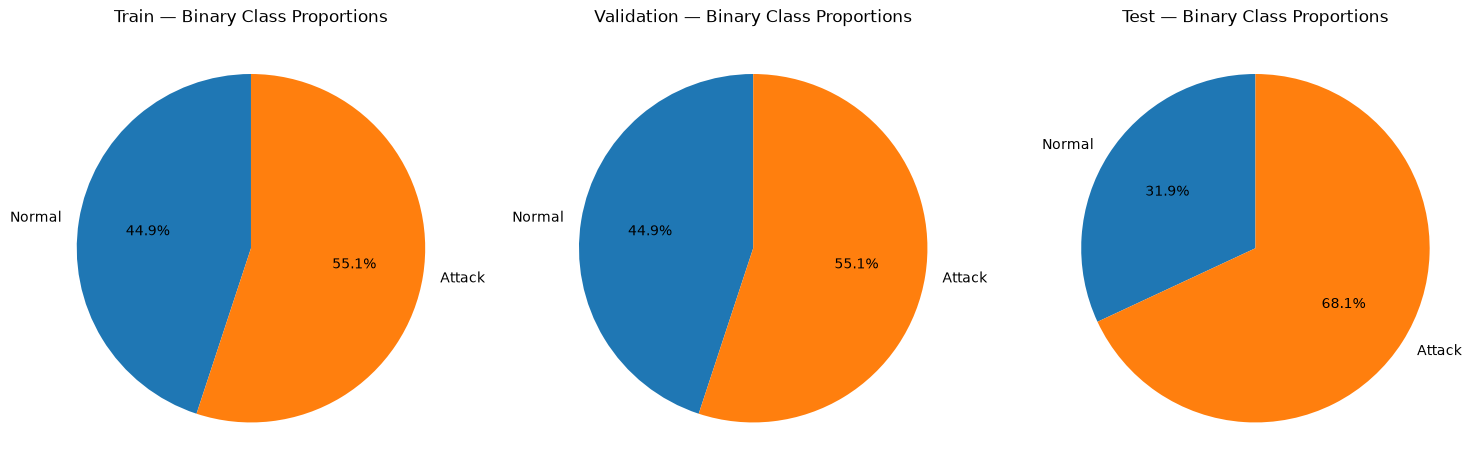

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, labels, name in zip(
    axes,
    [y_train_binary, y_val_binary, y_test_binary],
    ["Train", "Validation", "Test"]
):
    values, counts = np.unique(labels, return_counts=True)
    ax.pie(
        counts,
        labels=["Normal" if v == 0 else "Attack" for v in values],
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"{name} — Binary Class Proportions")

plt.tight_layout()
plt.show()


Save common feature arrays

In [18]:
np.save("../results/X_train_binary.npy", X_train)
np.save("../results/X_val_binary.npy", X_val)
np.save("../results/X_test_binary.npy", X_test)

# Features are identical for the binary and multiclass tasks (only the
# labels differ), but saved under both names so each downstream notebook
# can load its own self-contained set of files.
np.save("../results/X_train_multi.npy", X_train)
np.save("../results/X_val_multi.npy", X_val)
np.save("../results/X_test_multi.npy", X_test)

print("Feature arrays saved (binary_ and _multi variants, identical features).")


Feature arrays saved (binary_ and _multi variants, identical features).


Save binary labels

In [19]:
np.save(
    "../results/y_train_binary.npy",
    y_train_binary.astype("float32")
)

np.save(
    "../results/y_val_binary.npy",
    y_val_binary.astype("float32")
)

np.save(
    "../results/y_test_binary.npy",
    y_test_binary.astype("float32")
)

print("Binary labels saved.")

Binary labels saved.


Save multiclass labels

In [20]:
np.save(
    "../results/y_train_multi.npy",
    y_train_multi.astype("int32")
)

np.save(
    "../results/y_val_multi.npy",
    y_val_multi.astype("int32")
)

np.save(
    "../results/y_test_multi.npy",
    y_test_multi.astype("int32")
)

np.save(
    "../results/multiclass_names.npy",
    class_names
)

print("Multiclass labels and names saved.")

Multiclass labels and names saved.


Save preprocessing objects

In [21]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.joblib"
)

joblib.dump(
    multi_label_encoder,
    "../models/multiclass_label_encoder.joblib"
)

print("Preprocessing objects saved.")

Preprocessing objects saved.


Save transformed feature names

In [22]:
transformed_feature_names = (
    preprocessor.get_feature_names_out()
)

feature_names_df = pd.DataFrame({
    "Feature": transformed_feature_names
})

feature_names_df.to_csv(
    "../results/transformed_feature_names.csv",
    index=False
)

print(
    "Final number of transformed features:",
    len(transformed_feature_names)
)

feature_names_df.head(20)

Final number of transformed features: 190


,Feature
0,numeric__dur
1,numeric__spkts
2,numeric__dpkts
3,numeric__sbytes
4,numeric__dbytes
5,numeric__rate
6,numeric__sttl
7,numeric__dttl
8,numeric__sload
9,numeric__dload


Save preprocessing summary

In [23]:
preprocessing_summary = pd.DataFrame([{
    "Original Training Rows": len(train_df),
    "Official Test Rows": len(test_df),
    "Training Rows": len(X_train),
    "Validation Rows": len(X_val),
    "Testing Rows": len(X_test),
    "Original Features": len(feature_columns),
    "Numerical Features": len(numerical_columns),
    "Categorical Features": len(categorical_columns),
    "Transformed Features": X_train.shape[1],
    "Binary Classes": len(np.unique(y_train_binary)),
    "Multiclass Classes": len(class_names),
    "Random Seed": SEED
}])

preprocessing_summary.to_csv(
    "../results/preprocessing_summary.csv",
    index=False
)

preprocessing_summary

,Original Training Rows,Official Test Rows,Training Rows,Validation Rows,Testing Rows,Original Features,Numerical Features,Categorical Features,Transformed Features,Binary Classes,Multiclass Classes,Random Seed
0,82332,175341,65865,16467,175341,42,39,3,190,2,10,42


Final verification

In [25]:
print("=" * 60)
print(" PREPROCESSING COMPLETED")
print("=" * 60)

print("X_train:", X_train.shape, X_train.dtype)
print("X_val  :", X_val.shape, X_val.dtype)
print("X_test :", X_test.shape, X_test.dtype)

print("\nBinary labels")
print("Train:", y_train_binary.shape)
print("Val  :", y_val_binary.shape)
print("Test :", y_test_binary.shape)

print("\nMulticlass labels")
print("Train:", y_train_multi.shape)
print("Val  :", y_val_multi.shape)
print("Test :", y_test_multi.shape)

print("\nSaved files are available in:")
print("../results")
print("../models")

 PREPROCESSING COMPLETED
X_train: (65865, 190) float32
X_val  : (16467, 190) float32
X_test : (175341, 190) float32

Binary labels
Train: (65865,)
Val  : (16467,)
Test : (175341,)

Multiclass labels
Train: (65865,)
Val  : (16467,)
Test : (175341,)

Saved files are available in:
../results
../models
